In [2]:
# utils
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict

#sk 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans

#plot
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd 


### One basin, with timeline

##### Technical procedure:
- get cell states (predictors) and matching temp timeseries (target) (matching regarding the 365 warmup and also the inherent availability of discharge data maybe use dates)
- split into train- and test-set and train, return R² and RMSE 

_notes:_
- _don't return dataset, but return model and metadata (train period, test period, metrics)_

In [2]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
	cell_states = pickle.load(f)

In [3]:
with open("/home/wuhlmann/BA/data/processed_data/eda/normal_periods.pkl", "rb") as f: 
	discharge_coverage = pickle.load(f)

In [4]:
discharge_coverage.loc[1,:]

timeseries_length                                                     8036
start_date                                             1996-01-01 00:00:00
end_date                                               2017-12-31 00:00:00
n_normal_days                                                         7098
q5_q95_normal_periods    [[1996-01-04 00:00:00, 1996-01-05 00:00:00], [...
Name: 1, dtype: object

In [5]:
ts_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries")

In [6]:
path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/2_timeseries/daily")
model_coef = []

for basin_id in []: 

	ts = pd.read_table(ts_path / f"ID_{basin_id}.csv", header=0, sep=";")

	ts["date"] = pd.to_datetime(
				ts[["YYYY", "MM", "DD"]].rename(columns={"YYYY": "year", "MM": "month", "DD": "day"})
			)
	ts.set_index("date", inplace=True)

	# drop all columns except for 2m_mean_temp
	ts = ts[["2m_temp_mean"]]

	ts  = ts[discharge_coverage.loc[basin_id,"start_date"]:discharge_coverage.loc[basin_id, "end_date"]]
	c = StandardScaler().fit_transform(cell_states[str(basin_id)]["c_last"])
	
	ts =ts.iloc[-len(c):]
	
	print(f"diff of ts and c len: {len(ts) -len(c)}")
	dataset = np.c_[c, ts.values]

	model = ElasticNet()
	kfold = KFold(n_splits=5)
	folds = list(kfold.split(dataset[:,:-1], dataset[:,-1]))

	fig, axs = plt.subplots(5,1, figsize=(30,20))

	best_r2 = -100
	best_model_id = None
	coef_list = []

	for i, f, ax in zip([0,1,2,3,4],folds, axs):
		
		train_ids = f[0]
		test_ids = f[1]

		target = dataset[:,-1][test_ids]

		model.fit(X=dataset[:,:-1][train_ids], y=dataset[:,-1][train_ids])
		pred = model.predict(X=dataset[:,:-1][test_ids])

		coef_list.append(model.coef_)

		r2 = r2_score(target, pred)

		if r2 > best_r2: 
			best_r2 = r2
			best_model_id = i

		print(f"R2 of {r2:.2f} | MAE of {mean_absolute_error(target, pred)}")

		ax.plot(ts.index[test_ids], target, color="red", linewidth=0.4)
		ax.plot(ts.index[test_ids], pred, color="blue", linewidth=0.4)

	model_coef.append(coef_list[best_model_id])


we use c of day of prediction, since it most acuratly represents the condition of the day the model predicts

### Basin probes visualization

In [3]:
save_figs = False 

In [4]:
base_cell_state_path = Path("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states.p")

In [11]:
base_cell_state_path.stem

'q_pred_landcover_0903_135428_cell_states'

In [59]:
with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_2m_temp_mean_basin_probe.p", "rb") as f: 
	temp_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_prec_basin_probe.p", "rb") as f: 
	prec_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_total_et_basin_probe.p", "rb") as f: 
	total_et_basin_probe_results = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/probing/q_pred_landcover_0903_135428_cell_states_swe_basin_probe.p", "rb") as f: 
	swe_basin_probe_results = pickle.load(f)


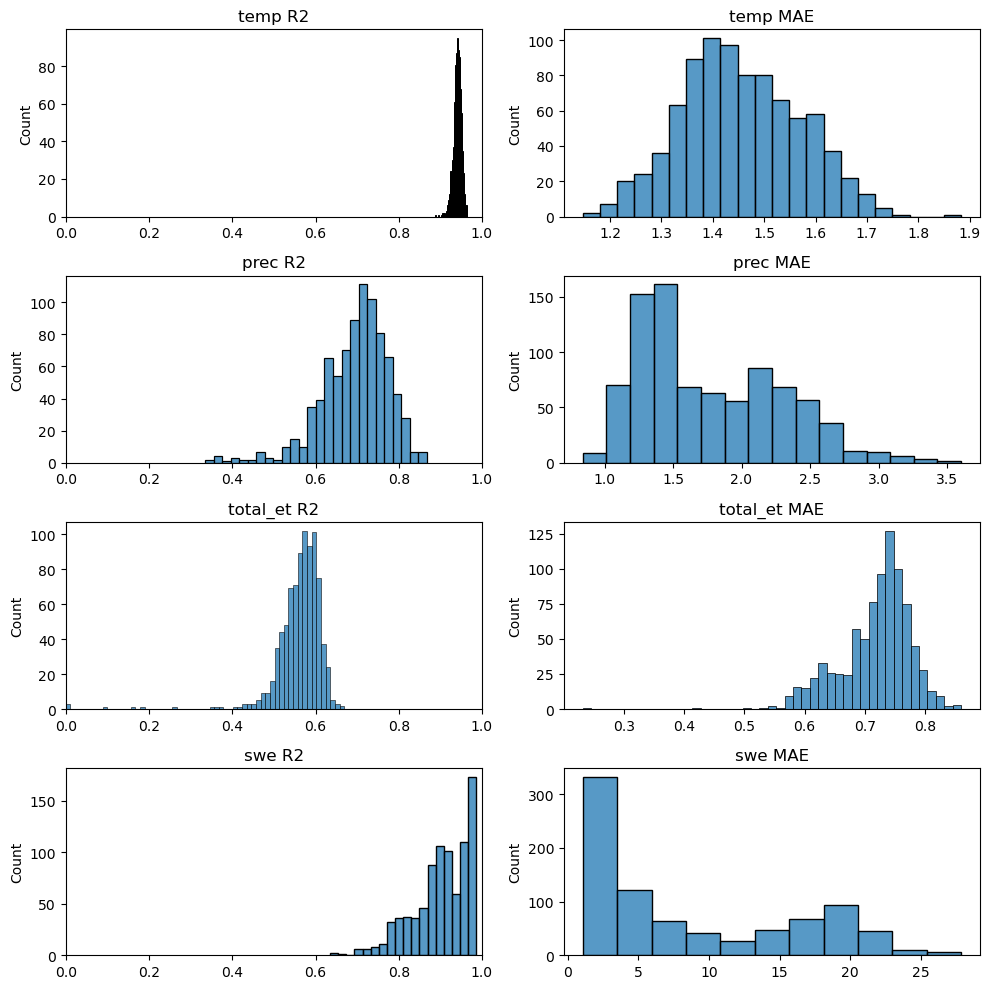

In [60]:
fig, axs = plt.subplots(4,2, figsize=(10,10))
axs = axs.ravel()

for i, probe, name in zip(
	list(range(0,8,2)),
	[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
	):
	 
	basin_keys = list(probe.keys())[1:]

	basins_r2 = [probe[b]["R2"] for b in basin_keys]
	basins_mae = [probe[b]["MAE"] for b in basin_keys]

	sns.histplot(basins_r2, ax=axs[i])
	axs[i].set_title(f"{name} R2")
	axs[i].set_xlim(0,1)
	sns.histplot(basins_mae, ax=axs[i+1])
	axs[i+1].set_title(f"{name} MAE")

plt.tight_layout()

In [61]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [62]:
strata_labels = {
	0: "alpine",
	1: "plateau",
	2: "transition"
}

In [63]:
def relevance_check(cell_state_col: pd.Series, participation_threshold: float) -> bool: 

	if (cell_state_col !=0).sum() >= len(cell_state_col) * participation_threshold:  
		return True
	else:
		return False

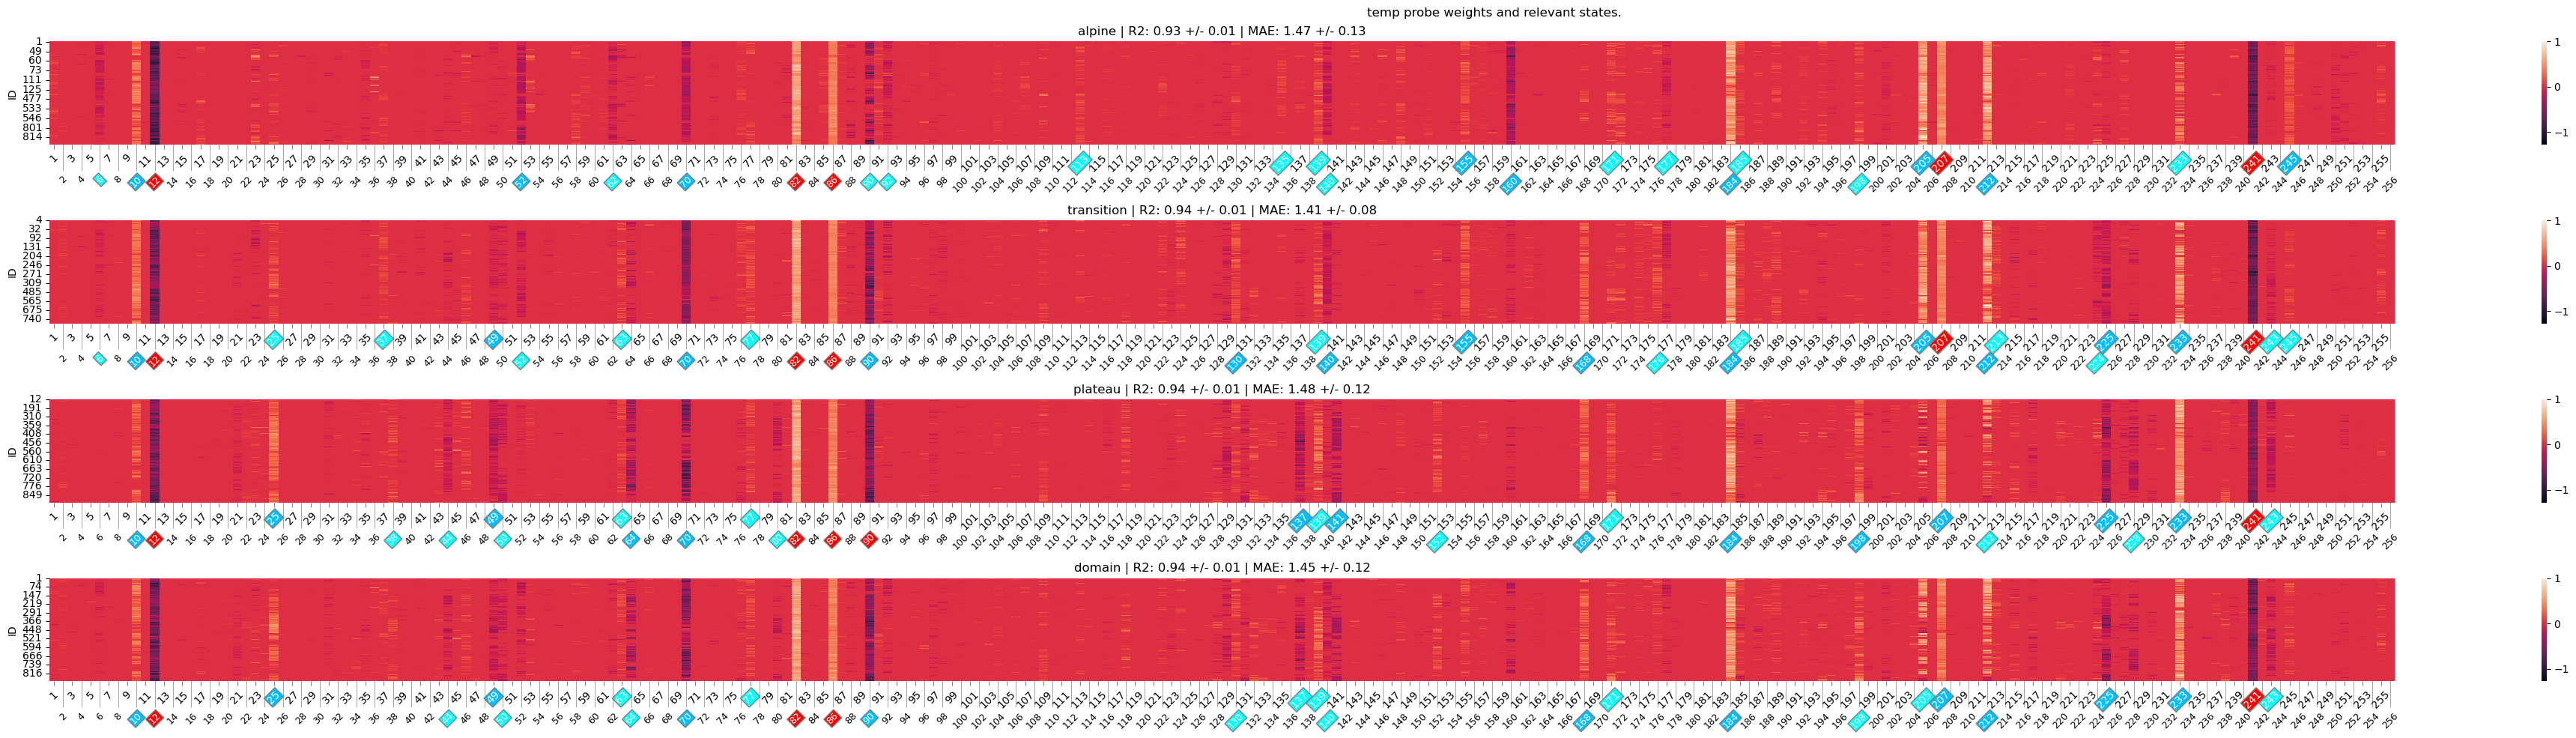

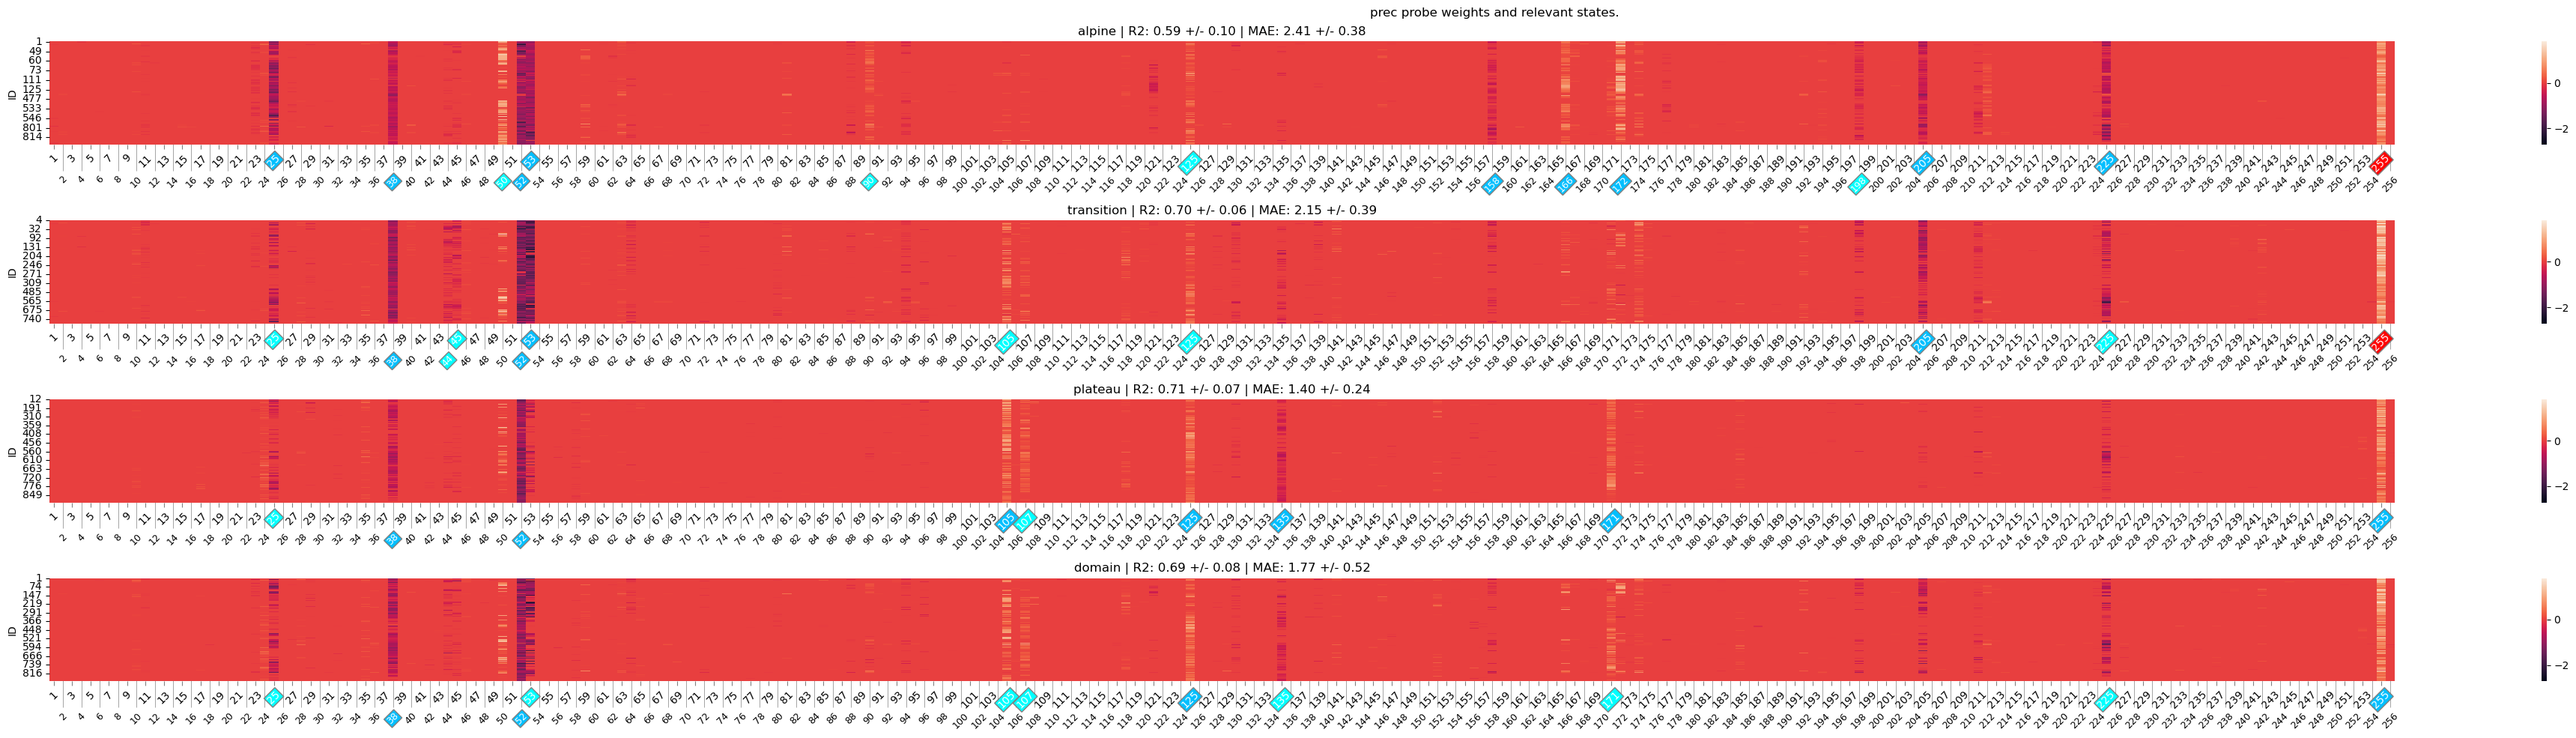

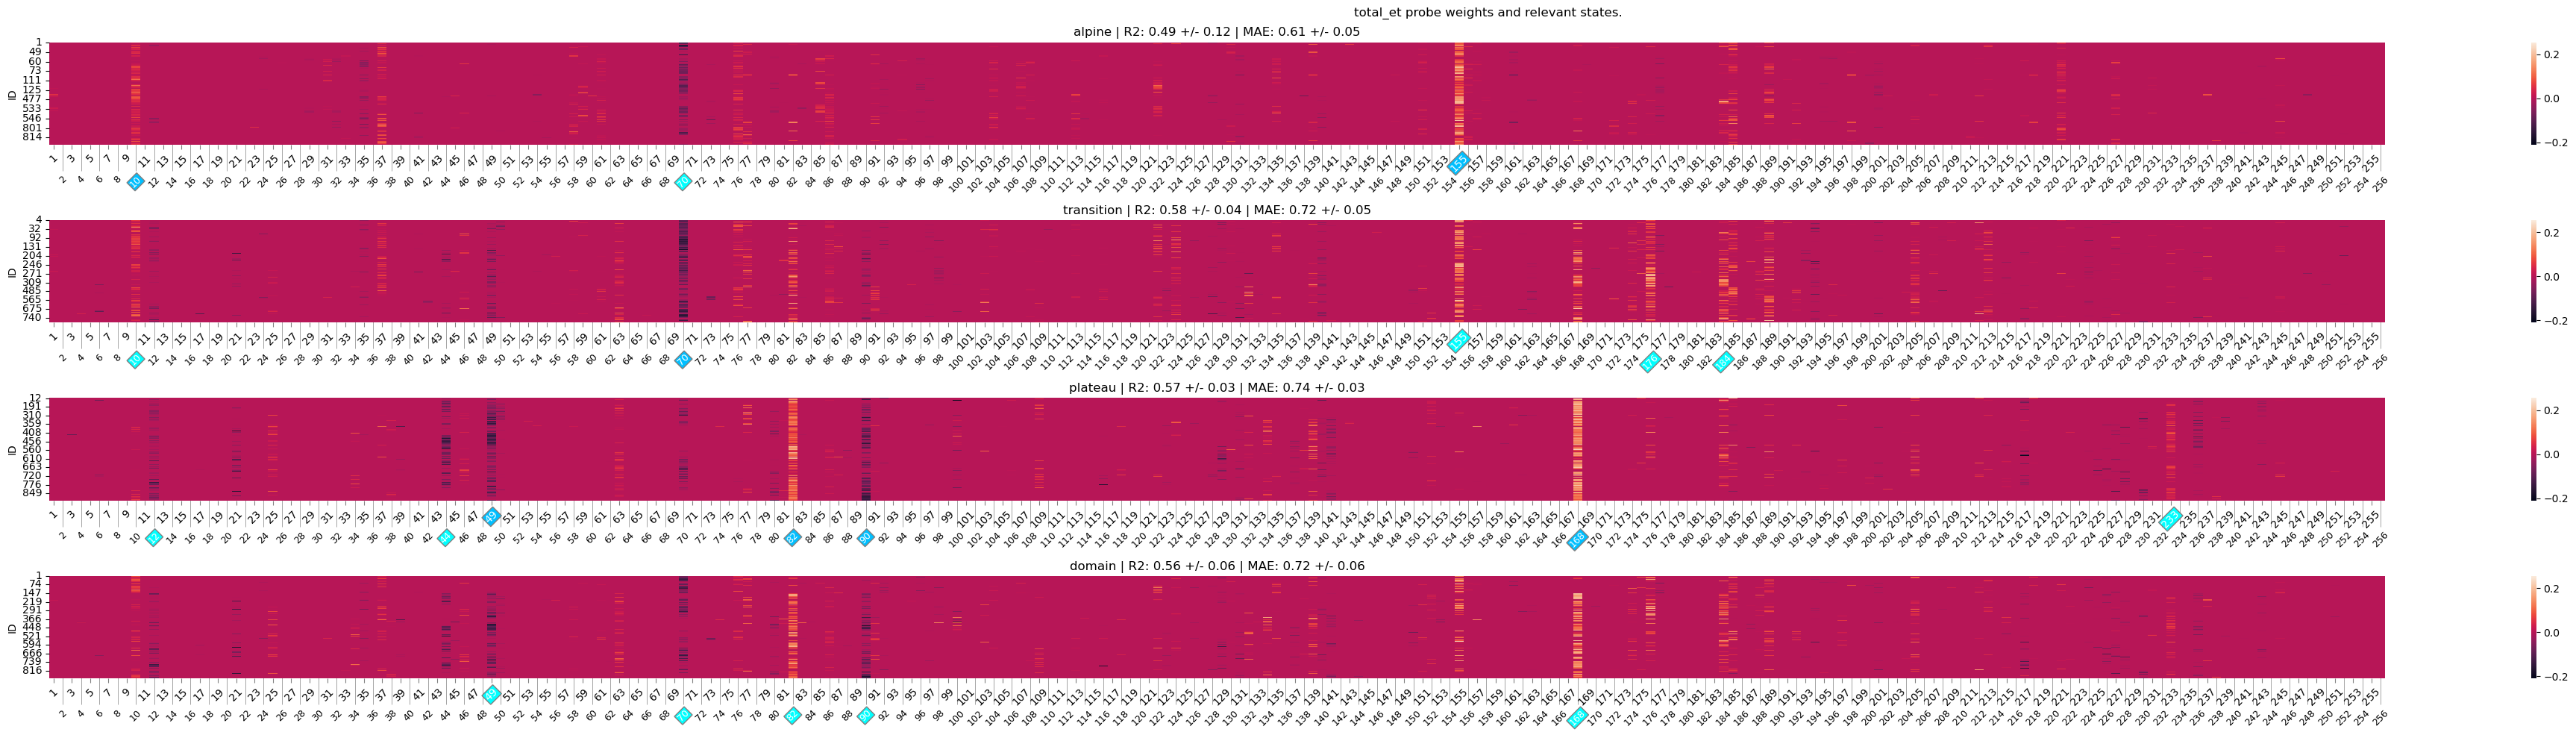

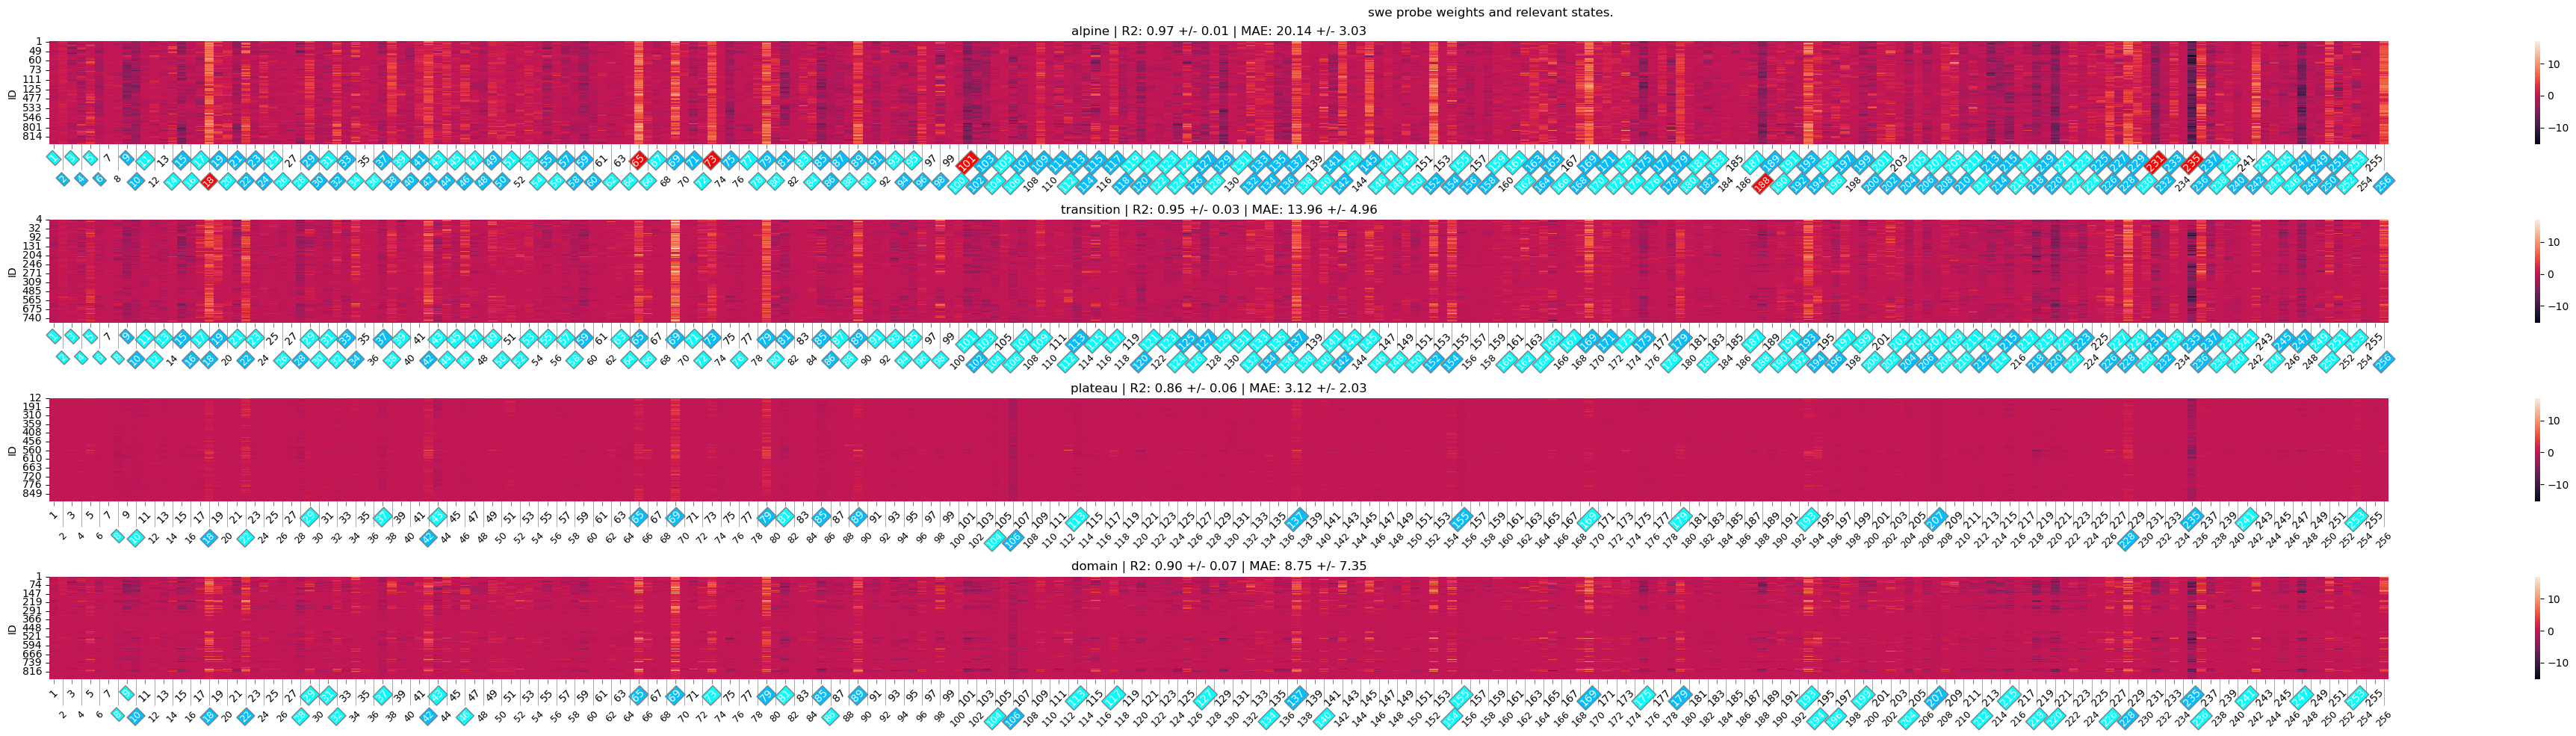

In [64]:
# dict to store state relevances
var_relevant_states = {}
var_name_list = ["temp", "prec", "total_et", "swe"]

for probe, name in zip([temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
                       var_name_list):
	
	#plot temp split between the three strata with the relevant states mark accordingly 
	relevance_level_colors = {
		0.5: "aqua",
		0.75: "deepskyblue",
		1.0 : "red"
	}

	#probe = prec_basin_probe_results

	rtwos_df = pd.DataFrame([probe[b]["R2"] for b in probe.keys()], index=strata_ids.index)
	maes_df = pd.DataFrame([probe[b]["MAE"] for b in probe.keys()], index=strata_ids.index)

	# stack weights and convert to df.
	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack, index=strata_ids.index)

	fig, axs = plt.subplots(4,1, figsize=(40,10))

	strata_relevant_states_df = pd.DataFrame(columns=range(1,257))

	for id, ax in zip([0,2,1,3], axs.ravel()):

		# only filter ids in the stratas.
		selected_basin_ids = strata_ids[strata_ids["0"] == id].index if not id == 3 else strata_ids.index

		# Filter out all basins not in the current strata. 
		selected_basin_weights = weights_df.loc[selected_basin_ids, :]
		state_relevance_list = [0]*256

		selected_basins_mean_r2 = float(rtwos_df.loc[selected_basin_ids,0].mean())
		selected_basins_std_r2 = float(rtwos_df.loc[selected_basin_ids,0].std())
		selected_basins_mean_mae = float(maes_df.loc[selected_basin_ids,0].mean())
		selected_basins_std_mae = float(maes_df.loc[selected_basin_ids,0].std())
		
		for threshold in [0.5, 0.75, 1.0]: 
			
			counter = 0

			# Check for each column (weight) how often it ist larger than 0
			for col in selected_basin_weights.columns: 

				if relevance_check(selected_basin_weights.loc[:,col], threshold):
					state_relevance_list[col]=threshold
					counter += 1

			strata_name = strata_labels[id] if not id == 3 else "domain"

			#print(f"{name} in {strata_name} strata has {counter} cell states with >= {threshold*100}% participation.") 

		# after iteration of all threshold save final state relevances for strata to df
		strata_relevant_states_df.loc[strata_name,:] = np.array(state_relevance_list)

		sns.heatmap(selected_basin_weights, ax=ax, vmax=weights_df.max(axis=None), vmin=weights_df.min(axis=None))
		ax.set_title(f"{strata_name} | R2: {selected_basins_mean_r2:.2f} +/- {selected_basins_std_r2:.2f} | MAE: {selected_basins_mean_mae:.2f} +/- {selected_basins_std_mae:.2f}")
		
		# nest x-axis to allow for all state ids to be displayed without cluttering
		ticks_odd = np.arange(0.5, 256, 2)
		labels_odd = [str(i) for i in range(1, 257, 2)]
		
		ticks_even = np.arange(1.5, 256, 2)
		labels_even = [str(i) for i in range(2, 257, 2)]

		ax.set_xticks(ticks_odd)
		ax.set_xticklabels(labels_odd)
		ax.tick_params(axis='x', length=4, color="gray", labelrotation=45) 

		sec_ax = ax.secondary_xaxis('bottom')
		sec_ax.spines["bottom"].set_position(("outward", 25)) 
		sec_ax.set_xticks(ticks_even)
		sec_ax.set_xticklabels(labels_even, fontsize=9)	
		sec_ax.tick_params(axis='x', direction='in', length=40, width=0.5, color='gray', labelrotation=45) 
		sec_ax.spines["bottom"].set_color("none")

		all_axes = [(ax, ticks_odd, labels_odd), (sec_ax, ticks_even, labels_even)]
		
		for current_ax, ticks, labels in all_axes:
					
			tick_labels = current_ax.get_xticklabels()
			
			for text_obj in tick_labels:
				
					state_num = int(text_obj.get_text())
					
					# shift state_num (which is the state label (1-indexed)) by one to align with 0-indexed list of state_relevance_list
					state_relevance = state_relevance_list[state_num-1]
					
					if state_relevance in relevance_level_colors.keys():
						
						color = relevance_level_colors[state_relevance]

						# Bounding Box setzen
						text_obj.set_bbox(dict(
							facecolor=color, 
							edgecolor='gray', 
							boxstyle='square',
							pad=0.1 
						))
						if not color == "lightblue": 
							text_obj.set_color("white")
	
	var_relevant_states[name] = strata_relevant_states_df

	fig.suptitle(f"{name} probe weights and relevant states.")
	plt.tight_layout()

	if save_figs: 
		fig.savefig(f"/home/wuhlmann/BA/repo/lamah-ce_lstm/results/probing/{name}_probe_weights_and_important_states.png")


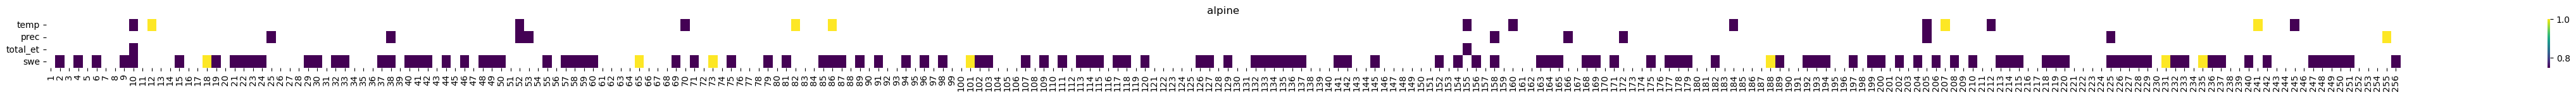

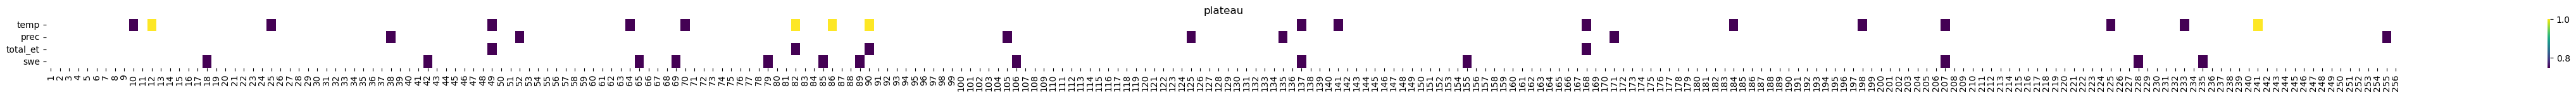

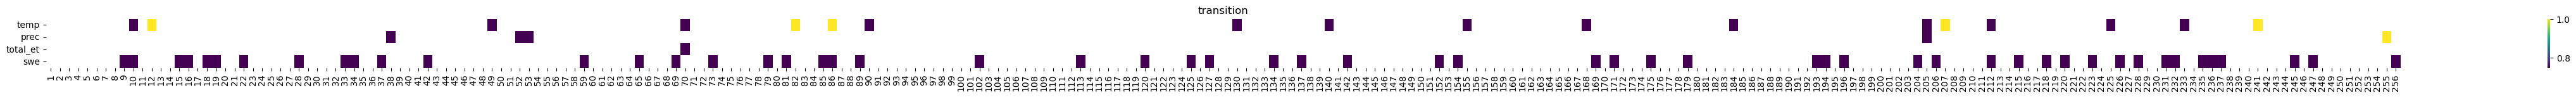

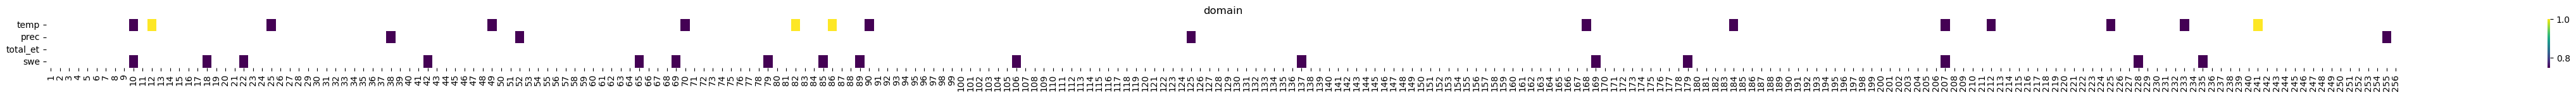

In [67]:
for strata in list(strata_labels.values()) + ["domain"]:
	var_domain_relevance_df = pd.DataFrame(data=[var_relevant_states[var].loc[strata] for var in var_name_list], index=var_name_list)

	fig, ax = plt.subplots(1,1, figsize=(60,1))
	sns.heatmap(var_domain_relevance_df[var_domain_relevance_df > 0.5], cmap="viridis")
	ax.set_title(strata)

In [68]:
var_domain_magnitude_df = pd.DataFrame(0, columns=range(1,257,1), index=var_name_list, dtype=float)
var_domain_activity_df = pd.DataFrame(0, columns=range(1,257,1), index=var_name_list, dtype=float)

# try out std importance score 
for probe_results, name in zip([temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
							   ["temp", "prec", "total_et", "swe"]): 
	
	weights = [probe_results[b]["coef"] for b in probe_results.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack, index=strata_ids.index)

	# get std of average weight vector
	sd = weights_df.mean(axis=0).std()

	print(f"Relevant cells for representing {name}")

	m_list = []
	a_list = []

	for cell_state in weights_df:

		cell_state_col = weights_df.loc[:,cell_state]

		# mean weight over all basins
		mean_cs_value = abs(cell_state_col.mean())
		magnitude = mean_cs_value // sd

		# determine percentage of basins where the cell is active
		activity = (cell_state_col !=0).sum() / len(cell_state_col) 

		if mean_cs_value // sd >=2:

			# importance score is the floor quotient of mean weight value and std of that cell state vector, multiplied with fraction of times the weight was above zero 
			print(cell_state+1, f"mag: {mean_cs_value//sd} ")
			
			m_list.append(magnitude)
		else: 
			m_list.append(0)
		
		if activity > 0.5: 
			print(cell_state+1, f"act: {activity} ")
			a_list.append(activity)
		else:
			a_list.append(0)

	var_domain_magnitude_df.loc[name, :] = m_list
	var_domain_activity_df.loc[name, :] = a_list


Relevant cells for representing temp
10 mag: 2.0 
10 act: 0.869615832363213 
12 mag: 5.0 
12 act: 1.0 
25 act: 0.7590221187427241 
44 act: 0.5238649592549476 
49 act: 0.7927823050058207 
50 act: 0.5145518044237486 
63 act: 0.529685681024447 
64 act: 0.5937136204889406 
70 mag: 4.0 
70 act: 0.9266589057043073 
77 act: 0.5913853317811408 
82 mag: 5.0 
82 act: 1.0 
86 mag: 4.0 
86 act: 1.0 
90 mag: 4.0 
90 act: 0.959254947613504 
130 act: 0.5785797438882422 
137 act: 0.570430733410943 
139 act: 0.6495925494761351 
140 act: 0.6286379511059371 
168 act: 0.8090803259604191 
171 act: 0.5867287543655413 
184 mag: 4.0 
184 act: 0.980209545983702 
198 act: 0.5762514551804424 
205 mag: 2.0 
205 act: 0.6752037252619325 
207 mag: 3.0 
207 act: 0.9941792782305006 
212 mag: 2.0 
212 act: 0.7625145518044237 
225 mag: 2.0 
225 act: 0.8172293364377182 
233 mag: 4.0 
233 act: 0.9010477299185099 
241 mag: 5.0 
241 act: 1.0 
243 act: 0.6577415599534342 
Relevant cells for representing prec
25 mag: 2.0 
25 

<Axes: >

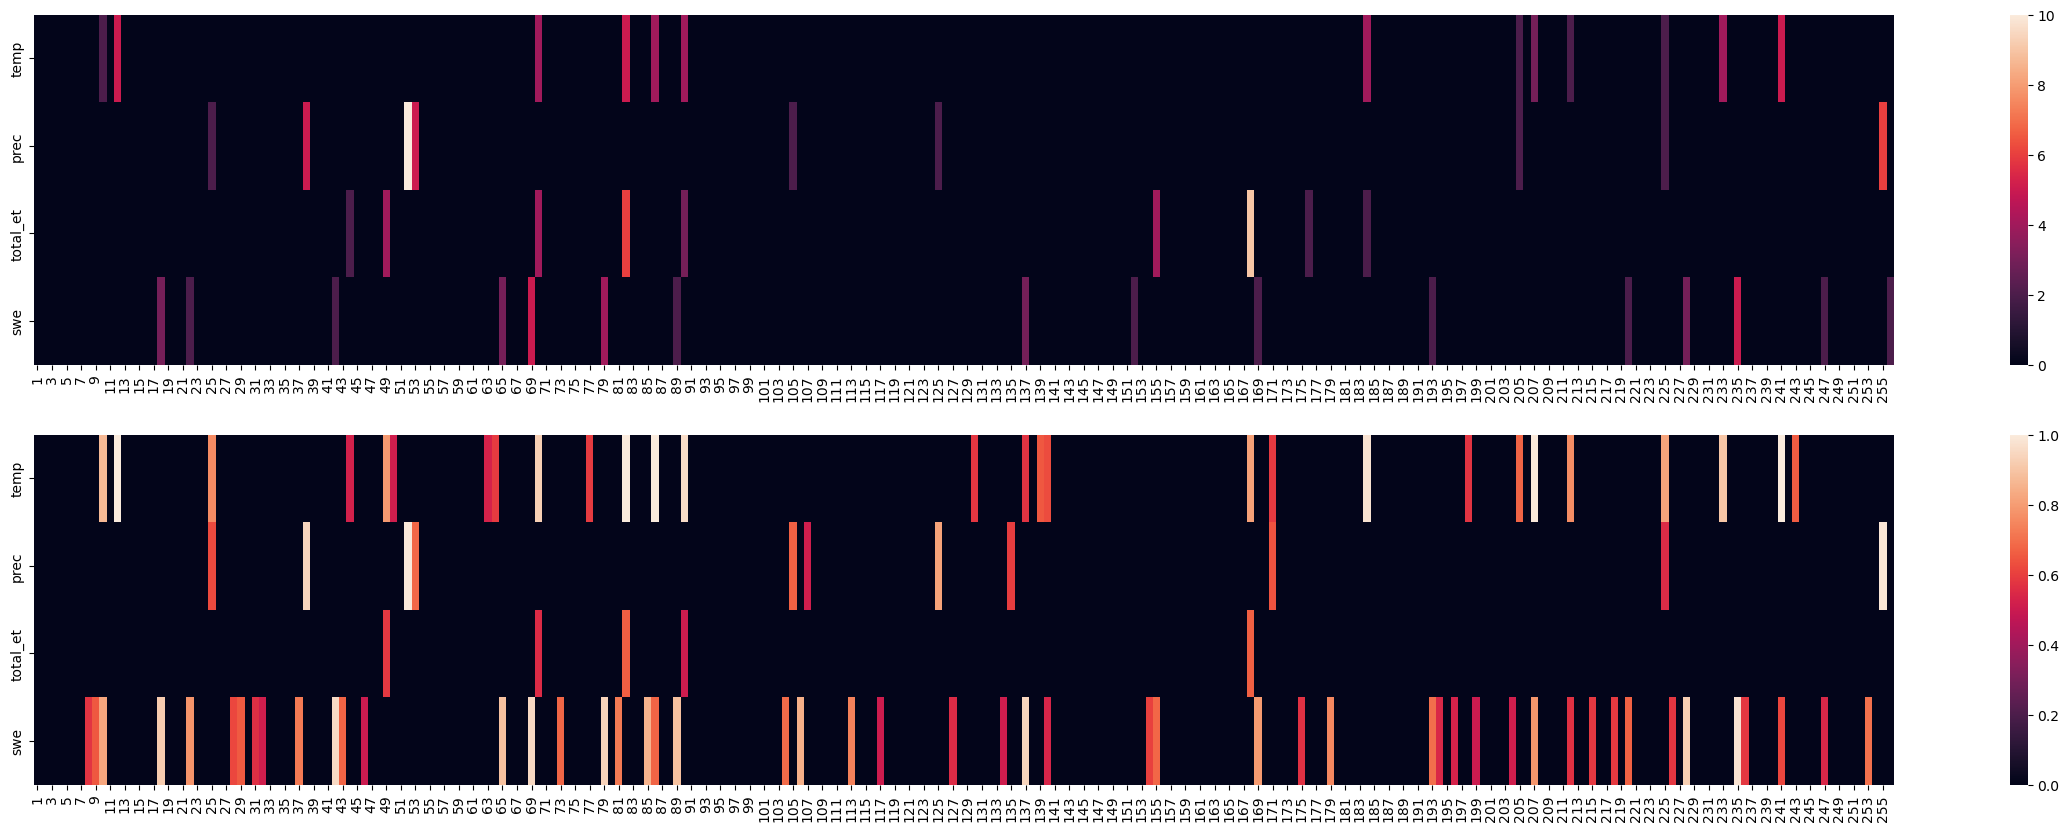

In [66]:
fig, axs = plt.subplots(2,1, figsize=(30,10))

sns.heatmap(var_domain_magnitude_df, ax=axs[0])
sns.heatmap(var_domain_activity_df, ax=axs[1])

#### Separate the weights by strata and look for locally important cell states.

In [18]:
#load .shp and sort index 
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf.sort_index(ascending=True, inplace=True)

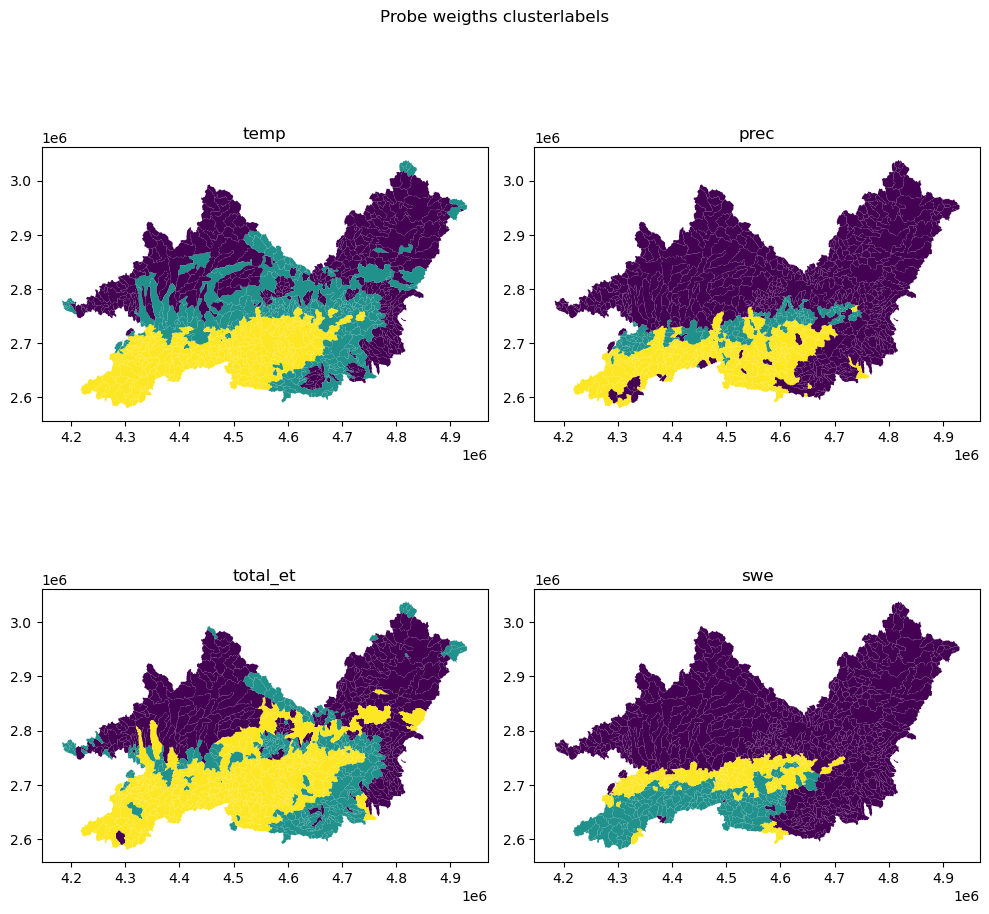

In [19]:
fig, axs = plt.subplots(2,2, figsize=(10,10))
fig.suptitle("Probe weigths clusterlabels")
kmeans = KMeans(3, random_state=134414)

for ax, probe, name in zip(
	axs.ravel(),
	[temp_basin_probe_results, prec_basin_probe_results, total_et_basin_probe_results, swe_basin_probe_results],
	["temp", "prec", "total_et", "swe"]
	):

	weights = [probe[b]["coef"] for b in probe.keys()]
	w_stack = np.vstack(weights)
	weights_df = pd.DataFrame(w_stack)
	
	probe_weights_labels = kmeans.fit_predict(weights_df)	

	col = f"{name}_labels"
	lamah_gdf[col] = probe_weights_labels
	lamah_gdf.plot(column=col, ax=ax)
	ax.set_title(f"{name}")

if save_figs:
	fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/basin_probe_weigths_cluster.png", dpi=300)

plt.tight_layout()

<Axes: >

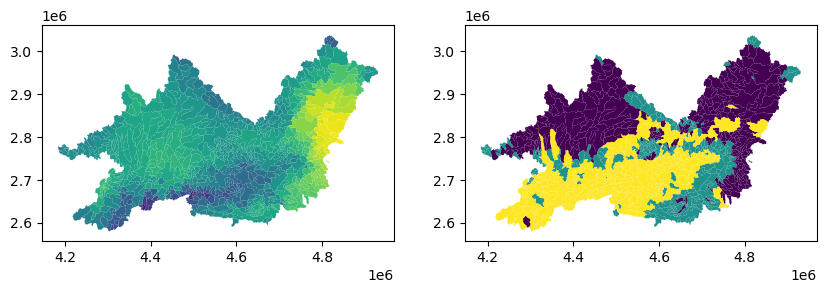

In [21]:
fig, axs = plt.subplots(1,2, figsize=(10,10))



lamah_gdf.plot(column="et0_mean", ax=axs[0])
lamah_gdf.plot(column="total_et_labels", ax=axs[1])



Maybe do MDS on probe weights, to identify possible clusters beyond the 3 stratas.

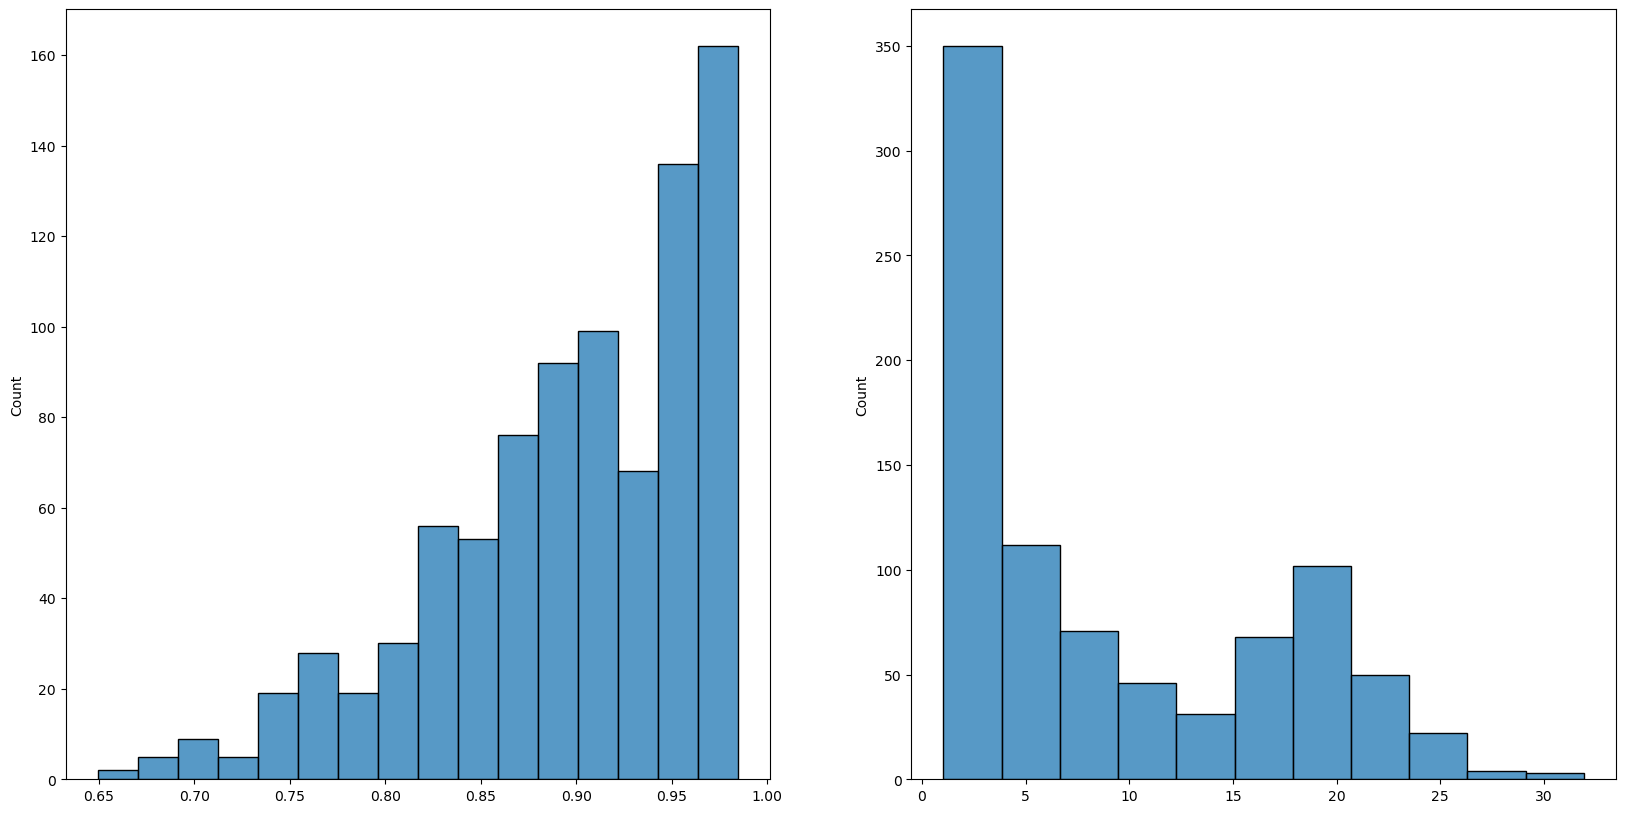

In [22]:
fig, axs = plt.subplots(1,2, figsize=(20,10))

for ax, metric in zip(axs, [rtwos, maes]): 
	
	sns.histplot(metric, ax=ax)